# Priority Classifier 

**Nessun prerequisito Colab** — gli embedding vengono calcolati localmente su CPU (o caricati dalla cache se già esistenti).

### Pipeline
1. Carica `dataset_clean.csv` e split temporale
2. Calcola embedding **intfloat/multilingual-e5-base** su CPU (con caching su disco)
3. Feature engineering OHE
4. Tuning C con 3-fold CV
5. Training LinearSVC + valutazione
6. Salvataggio in `modelli/priority_v2/`


---
## STEP 1 — Caricamento dataset e split temporale

In [1]:
import pandas as pd
import numpy as np
import warnings
import time
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# Il kernel VS Code parte dalla cartella notebooks/, non dalla root del progetto.
# os.path.abspath('') restituisce la directory corrente del kernel,
# quindi .parent risale di un livello e otteniamo la root di TicketClassifier/.
BASE_DIR = Path(os.path.abspath('')).parent

DATA_DIR = BASE_DIR / 'data'
EMB_DIR  = BASE_DIR / 'embeddings'
MOD_DIR  = BASE_DIR / 'modelli'

# Lo split e' temporale (non random) per simulare un vero scenario produttivo:
# il modello viene addestrato su dati storici e valutato su dati futuri.
# Uno split random sovrastimerebbe le performance perche' ticket simili
# (stesso cliente, stesso tipo di problema) finirebbero sia in train che in test.
SOGLIA_SPLIT = '2025-11-01'

df = pd.read_csv(DATA_DIR / 'dataset_clean.csv', parse_dates=['data_creazione'])

df_train = df[df['data_creazione'] < SOGLIA_SPLIT].copy()
df_test  = df[df['data_creazione'] >= SOGLIA_SPLIT].copy()

print(f"Dataset totale  : {len(df):,} ticket")
print(f"Train (<{SOGLIA_SPLIT})  : {len(df_train):,}")
print(f"Test  (>={SOGLIA_SPLIT}) : {len(df_test):,}")
print(f"\nDistribuzione priorita' — train:")
print(df_train['priorita_finale'].value_counts().sort_index())
print(f"\nDistribuzione priorita' — test:")
print(df_test['priorita_finale'].value_counts().sort_index())

Dataset totale  : 58,385 ticket
Train (<2025-11-01)  : 46,353
Test  (>=2025-11-01) : 12,032

Distribuzione priorita' — train:
priorita_finale
P1     6510
P2    13665
P3    24958
P4     1220
Name: count, dtype: int64

Distribuzione priorita' — test:
priorita_finale
P1    1621
P2    3333
P3    6825
P4     253
Name: count, dtype: int64


---
## STEP 2 — Calcolo embedding E5 su CPU (con caching su disco)

Il testo viene prefissato con `query: ` come richiesto dal modello **intfloat/multilingual-e5-base**.  
Se i file `.npy` esistono gia' nella cartella `embeddings/` vengono caricati direttamente,
altrimenti vengono calcolati su CPU e salvati per le run successive.

In [2]:
from sentence_transformers import SentenceTransformer

MODEL_NAME     = 'intfloat/multilingual-e5-base'
EMB_TRAIN_PATH = EMB_DIR / 'priority_v1_e5_train.npy'
EMB_TEST_PATH  = EMB_DIR / 'priority_v1_e5_test.npy'

# Carica embedding se già esistono, altrimenti li calcola e li salva
def get_embeddings(df, path):
    if path.exists():
        print(f"Carico {path.name}...")
        return np.load(path)
    
    # Il calcolo su CPU richiede diversi minuti — viene fatto solo una volta
    print(f"Calcolo embeddings su CPU (questo potrebbe richiedere diversi minuti)...")
    model = SentenceTransformer(MODEL_NAME, device='cpu')
    emb = model.encode(
        ("query: " + df['testo_input'].astype(str)).tolist(),
        batch_size=64,              # batch più grandi = più veloce ma più RAM
        normalize_embeddings=True,  # norma L2 = 1.0 → dot product equivale a cosine similarity
        show_progress_bar=True,
    )
    np.save(path, emb)
    return emb

X_emb_train = get_embeddings(df_train, EMB_TRAIN_PATH)
X_emb_test  = get_embeddings(df_test,  EMB_TEST_PATH)

print(f"Train: {X_emb_train.shape} | Test: {X_emb_test.shape}")

Carico priority_v1_e5_train.npy...
Carico priority_v1_e5_test.npy...
Train: (46353, 768) | Test: (12032, 768)


---
## STEP 3 OneHotEncoding

In [3]:
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder

CAT_COLS  = ['priorita_iniziale_cliente']

# Il fit viene fatto solo su train per evitare data leakage:
# il modello non deve "vedere" quali categorie esistono nel test set.
# handle_unknown='ignore': se nel test compare una categoria non vista in train,
# produce un vettore di zeri invece di dare errore
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder.fit(df_train[CAT_COLS])

X_cat_train = encoder.transform(df_train[CAT_COLS])
X_cat_test  = encoder.transform(df_test[CAT_COLS])

print(f"Feature categoriche (OHE): {X_cat_train.shape[1]} colonne")
print(f"  Categorie: {encoder.categories_[0].tolist()}")

Feature categoriche (OHE): 4 colonne
  Categorie: ['P1', 'P2', 'P3', 'P4']


In [4]:
import numpy as np
from pathlib import Path

EMB_DIR = Path(r'C:\Users\matteo.segatto\Desktop\TicketClassifier\embeddings')

emb_train = np.load(EMB_DIR / 'priority_v1_e5_train.npy')
emb_test  = np.load(EMB_DIR / 'priority_v1_e5_test.npy')

print(f'Embedding train : {emb_train.shape[0]}')
print(f'Embedding test  : {emb_test.shape[0]}')
print()
print(f'df_train        : {len(df_train)}')
print(f'df_test         : {len(df_test)}')
print()
print(f'Diff train: {len(df_train) - emb_train.shape[0]:+d}')
print(f'Diff test : {len(df_test)  - emb_test.shape[0]:+d}')

Embedding train : 46353
Embedding test  : 12032

df_train        : 46353
df_test         : 12032

Diff train: +0
Diff test : +0


---
## STEP 4 — Costruzione feature matrix finale

Combiniamo le due componenti in un'unica matrice sparsa:

In [5]:
# Converti embedding densi in sparse per hstack
X_emb_train_sp = sp.csr_matrix(X_emb_train)
X_emb_test_sp  = sp.csr_matrix(X_emb_test)

# hstack: unisce colonna per colonna i due blocchi di feature
X_train = sp.hstack([X_emb_train_sp, X_cat_train])
X_test  = sp.hstack([X_emb_test_sp,  X_cat_test])

y_train = df_train['priorita_finale'].values
y_test  = df_test['priorita_finale'].values

print(f"Feature matrix train: {X_train.shape}")
print(f"Feature matrix test:  {X_test.shape}")
print(f"  └── embedding:   768 colonne")
print(f"  └── OHE categ.:  {X_cat_train.shape[1]} colonne")
print(f"  └── TOTALE:      {X_train.shape[1]} colonne")
print(f"\nClassi target: {np.unique(y_train)}")

Feature matrix train: (46353, 772)
Feature matrix test:  (12032, 772)
  └── embedding:   768 colonne
  └── OHE categ.:  4 colonne
  └── TOTALE:      772 colonne

Classi target: ['P1' 'P2' 'P3' 'P4']


---
## STEP 5 — Tuning parametro C con cross-validation

Cerchiamo il C ottimale per LinearSVC.  
C regola il tradeoff bias/varianza:
- **C piccolo** (0.01): forte regolarizzazione, puo' underfitare
- **C grande** (10): poca regolarizzazione, puo' overfitare su train

Con embedding gia' L2-normalizzati, i valori ottimali tipici sono tra 0.1 e 5.0.  
Usiamo 3-fold CV (non 5) per velocita' — su 46k ticket e' gia' robusto.

In [6]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# C regola il tradeoff bias/varianza in LinearSVC:
# valori piccoli (0.01) → forte regolarizzazione, puo' underfitare
# valori grandi (10)    → poca regolarizzazione, puo' overfitare su train
# Con embedding gia' L2-normalizzati i valori ottimali tipici stanno tra 0.1 e 5.0
VALORI_C = [0.1, 0.5, 1.0, 5.0]

# StratifiedKFold garantisce che ogni fold abbia la stessa proporzione di classi,
# importante perche' P4 e' solo il 2.5% del dataset e uno split casuale potrebbe
# escluderlo quasi del tutto da qualche fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)")
print(f"{'C':>6}  {'F1 macro':>10}  {'Std':>8}  {'Tempo':>8}")
print("-" * 42)

risultati_c = {}
for c in VALORI_C:
    clf_tmp = LinearSVC(class_weight='balanced', max_iter=3000, C=c, random_state=42)
    t0 = time.time()
    scores = cross_val_score(
        clf_tmp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    elapsed = time.time() - t0
    risultati_c[c] = scores.mean()
    print(f"{c:>6.2f}  {scores.mean():>10.4f}  {scores.std():>8.4f}  {elapsed:>7.0f}s")

C_OTTIMALE = max(risultati_c, key=risultati_c.get)
print(f"\nC ottimale selezionato: {C_OTTIMALE}  (F1 macro = {risultati_c[C_OTTIMALE]:.4f})")

Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)
     C    F1 macro       Std     Tempo
------------------------------------------
  0.10      0.8555    0.0019       33s
  0.50      0.8568    0.0018       40s
  1.00      0.8578    0.0016       43s
  5.00      0.8583    0.0014       44s

C ottimale selezionato: 5.0  (F1 macro = 0.8583)


---
## STEP 6 — Training e valutazione finale

In [7]:
from sklearn.metrics import classification_report, f1_score

print(f"Training LinearSVC con C={C_OTTIMALE}...")
t0 = time.time()

clf = LinearSVC(
    class_weight='balanced',  # compensa lo sbilanciamento: senza questo P4 (2.5%) verrebbe quasi ignorato
    max_iter=3000,
    C=C_OTTIMALE,
    random_state=42
)
clf.fit(X_train, y_train)
print(f"Training completato in {time.time()-t0:.1f}s")

y_pred = clf.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
accuracy  = (y_pred == y_test).mean()

print(f"\n{'='*60}")
print(f"RISULTATI CLASSIFICATORE PRIORITA' v2 (E5-base + LinearSVC)")
print(f"{'='*60}")
print(f"Macro F1:  {macro_f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print()
print(classification_report(y_test, y_pred, digits=3))

Training LinearSVC con C=5.0...
Training completato in 50.5s

RISULTATI CLASSIFICATORE PRIORITA' v2 (E5-base + LinearSVC)
Macro F1:  0.8441
Accuracy:  0.8835

              precision    recall  f1-score   support

          P1      0.632     0.953     0.760      1621
          P2      0.871     0.809     0.839      3333
          P3      0.985     0.908     0.945      6825
          P4      0.945     0.743     0.832       253

    accuracy                          0.883     12032
   macro avg      0.858     0.853     0.844     12032
weighted avg      0.905     0.883     0.889     12032



---
## STEP 7 — Analisi pesi delle features

In [8]:
# Analisi importanza gruppi di feature (embedding vs categoriche vs urgenza)
# Stesso calcolo della v1 — confrontiamo i valori

n_emb  = 768
n_cat  = X_cat_train.shape[1]

print("=== Peso medio assoluto per gruppo di feature ===")
print(f"{'Classe':<8} {'Embedding':>12} {'Priorità_cli':>14}")
print("-" * 52)

for i, classe in enumerate(clf.classes_):
    coef = clf.coef_[i]
    peso_emb  = np.abs(coef[:n_emb]).mean()
    peso_cat  = np.abs(coef[n_emb:n_emb+n_cat]).mean()
    peso_bool = np.abs(coef[n_emb+n_cat:]).mean()
    print(f"{classe:<8} {peso_emb:>12.4f} {peso_cat:>14.4f}")

print()

=== Peso medio assoluto per gruppo di feature ===
Classe      Embedding   Priorità_cli
----------------------------------------------------
P1             0.9763         0.9143
P2             0.6374         0.7953
P3             0.3063         0.6652
P4             1.5794         1.1249



---
## STEP 8 — Confusion matrix e analisi errori

<Figure size 1400x500 with 0 Axes>

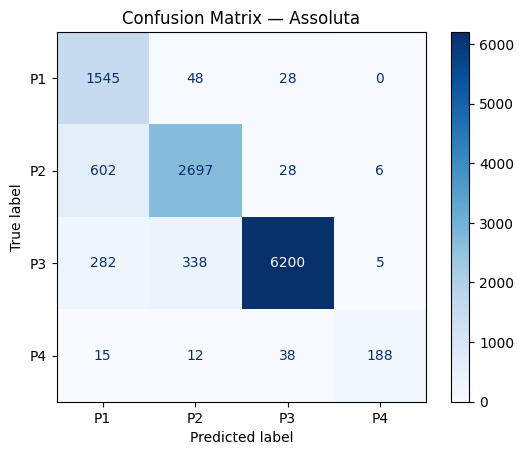


Errori totali: 1,402 su 12,032 (11.7%)

Top coppie di confusione:
reale  predetto
P2     P1          602
P3     P2          338
       P1          282
P1     P2           48
P4     P3           38
P1     P3           28
P2     P3           28
P4     P1           15


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


plt.figure(figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Blues'
)

plt.title('Confusion Matrix — Assoluta')
plt.show()

# Errori più frequenti
df_err = pd.DataFrame({'reale': y_test, 'predetto': y_pred})
errori = df_err[df_err['reale'] != df_err['predetto']]
print(f"\nErrori totali: {len(errori):,} su {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)")
print("\nTop coppie di confusione:")
print(
    errori.groupby(['reale', 'predetto']).size()
    .sort_values(ascending=False).head(8).to_string()
)

---
## STEP 9 — Salvataggio modello

In [10]:
import joblib
import json

SAVE_DIR = MOD_DIR / 'priority_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Salvo classificatore e OHE separatamente:
# in produzione servono entrambi — prima si OHE la priorita' cliente,
# poi si costruisce X e si predice con il classificatore
joblib.dump(clf,     SAVE_DIR / 'classificatore_svc.pkl')
joblib.dump(encoder, SAVE_DIR / 'ohe_encoder.pkl')

# Il file metadata.json contiene tutto il necessario per ricaricare
# e usare il modello in un altro script senza riaprire il notebook
metadata = {
    'versione': 'v2',
    'modello_embedding': 'intfloat/multilingual-e5-base',
    'prefisso_e5': 'query: ',           # da anteporre a ogni testo prima di chiamare .encode()
    'classificatore': 'LinearSVC',
    'C_ottimale': C_OTTIMALE,
    'feature': [
        'embedding_e5_768d',
        'priorita_iniziale_cliente_ohe',
        'has_urgenza'
    ],
    'classi': clf.classes_.tolist(),
    'split': 'temporale',
    'soglia_split': SOGLIA_SPLIT,
    'macro_f1_test': round(float(f1_score(y_test, y_pred, average='macro')), 4),
    'accuracy_test': round(float((y_pred == y_test).mean()), 4),
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'keyword_urgenza': ['urgente', 'immediato', 'il prima possibile', 'critico']
}

with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Modello salvato in: {SAVE_DIR}")
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modello salvato in: c:\Users\matteo.segatto\Desktop\TicketClassifier\modelli\priority_v2

{
  "versione": "v2",
  "modello_embedding": "intfloat/multilingual-e5-base",
  "prefisso_e5": "query: ",
  "classificatore": "LinearSVC",
  "C_ottimale": 5.0,
  "feature": [
    "embedding_e5_768d",
    "priorita_iniziale_cliente_ohe",
    "has_urgenza"
  ],
  "classi": [
    "P1",
    "P2",
    "P3",
    "P4"
  ],
  "split": "temporale",
  "soglia_split": "2025-11-01",
  "macro_f1_test": 0.8441,
  "accuracy_test": 0.8835,
  "n_train": 46353,
  "n_test": 12032,
  "keyword_urgenza": [
    "urgente",
    "immediato",
    "il prima possibile",
    "critico"
  ]
}
